In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
import warnings

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'Arial'

# ── Base parameters (Yang et al. 2023) ───────────────────────────────────────
CFG = {
    'S1': 2.0, 'S2': 1.0, 'S3': 1.0,
    'd_aSyn': 15.0, 'K': 8.5, 'n': 4.0,
    'k1': 0.72,  'k2': 0.72,
    'k3': 0.7,   'k4': 0.7,  'k5': 2.7,
    'k6': 1.0,   'k7': 0.5,  'k8': 1.0,  'ERST': 2.0,
    'k9': 2.0,   'k10': 10.0,'k11': 0.4, 'k12': 7.0, 'mTORT': 1.0,
    'k13': 2.0,  'k14': 4.0, 'k15': 1.0,
    'k16': 10.0, 'k17': 0.6, 'Jbe': 1.0, 'Beclin1T': 1.0,
    'k18': 1.0,  'k19': 2.0, 'k20': 2.0,
    'k21': 2.0,  'k22': 4.5, 'Jca': 0.04,'CaspasesT': 1.0,
}

# ── Transport parameters ──────────────────────────────────────────────────────
TR = {
    'DROS':      6.5e6,
    'DERS':      3.6e4,
    'DmTOR':     36.0,
    'DBeclin1':  5.4e4,
    'DCaspases': 7.2e4,
    'vlyso':     7200.0,   # mTOR retrograde
    'vB':        36.0,     # Beclin1 anterograde
    'vC':        36.0,     # Caspases anterograde
}

# ── Grid ─────────────────────────────────────────────────────────────────────
L   = 1000.0
Nx  = 100
dx  = L / Nx
x   = np.linspace(0, L, Nx)

species_names = ['ROS', 'aSyn*', 'ERS', 'mTOR', 'Beclin1', 'Caspases']
print("Setup complete.")

Setup complete.


In [2]:
def pde_rhs_yang(t, y_flat, p, dx, Nx):
    """
    Spatial PDE: Yang kinetics + diffusion + advection.
    State ordering: [ROS | aSyn* | ERS | mTOR | Beclin1 | Caspases]
    Each block has Nx points.

    With UNIFORM IC: all spatial gradients = 0 at t=0.
    Transport terms vanish → each grid point evolves as Yang ODE.
    This is the homogeneous validation test.
    """
    ROS  = np.maximum(y_flat[0*Nx:1*Nx], 0)
    A    = np.maximum(y_flat[1*Nx:2*Nx], 0)
    ERS  = np.maximum(y_flat[2*Nx:3*Nx], 0)
    mTOR = np.maximum(y_flat[3*Nx:4*Nx], 0)
    B1   = np.maximum(y_flat[4*Nx:5*Nx], 0)
    Casp = np.maximum(y_flat[5*Nx:6*Nx], 0)

    # ── Spatial operators ────────────────────────────────────────────────────
    def laplacian(u):
        d2u = np.zeros(Nx)
        d2u[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
        d2u[0]    = (u[1]  - u[0]) / dx**2        # Neumann left
        d2u[-1]   = (u[-2] - u[-1]) / dx**2       # Neumann right
        return d2u

    def upwind(u, v):
        """Upwind advection: -v * du/dx"""
        du = np.zeros(Nx)
        if v > 0:    # anterograde (+x): backward difference
            du[1:]  = -(v/dx) * (u[1:] - u[:-1])
            du[0]   = 0.0
        elif v < 0:  # retrograde (-x): forward difference
            du[:-1] = -(v/dx) * (u[1:] - u[:-1])
            du[-1]  = 0.0
        return du

    # ── Nonlinear reaction terms (Yang et al. 2023) ───────────────────────────
    Hill = A**p['n'] / (p['K']**p['n'] + A**p['n'])

    # ROS — Eq (1)
    f_ROS  = (p['k1']*(1 + p['S1'] + p['d_aSyn']*Hill)
              - p['k2']*ROS*p['S2'])

    # aSyn* — Eq (2): immobile, pool-bounded clearance
    f_A    = p['k3']*ROS*p['S3'] - p['k4']*p['k5']*A*B1*mTOR

    # ERS — Eq (3)
    f_ERS  = (p['k6']*A*p['k7']*(p['ERST'] - ERS)
              - p['k8']*ERS)

    # mTOR — Eq (4): distributed pool-bounded activation
    MT_avail = np.maximum(p['mTORT'] - mTOR, 0)
    f_mTOR = ((p['k9'] + p['k10']*ERS)*MT_avail
              - (p['k11'] + p['k12']*B1)*mTOR)

    # Beclin1 — Eq (5): distributed pool-bounded activation
    BT_avail = np.maximum(p['Beclin1T'] - B1, 0)
    act_B    = ((p['k13'] + p['k14']*ERS)
                * BT_avail / (p['Jbe'] + BT_avail + 1e-12))
    inact_B  = ((p['k15'] + p['k16']*Casp + p['k17']*mTOR)
                * B1 / (p['Jbe'] + B1 + 1e-12))
    f_B1   = act_B - inact_B

    # Caspases — Eq (6)
    CT = p['CaspasesT']
    act_C   = ((p['k18'] + p['k19']*ERS + p['k20']*mTOR)
               * (CT - Casp) / (p['Jca'] + CT - Casp + 1e-12))
    inact_C = ((p['k21'] + p['k22']*B1)
               * Casp / (p['Jca'] + Casp + 1e-12))
    f_Casp = act_C - inact_C

    # ── Transport terms ──────────────────────────────────────────────────────
    t_ROS  = TR['DROS']      * laplacian(ROS)
    t_ERS  = TR['DERS']      * laplacian(ERS)
    t_mTOR = (TR['DmTOR']    * laplacian(mTOR)
              + upwind(mTOR, -TR['vlyso']))   # retrograde
    t_B1   = (TR['DBeclin1'] * laplacian(B1)
              + upwind(B1,    TR['vB']))      # anterograde
    t_Casp = (TR['DCaspases']* laplacian(Casp)
              + upwind(Casp,  TR['vC']))      # anterograde

    # aSyn* has no transport
    return np.concatenate([
        t_ROS  + f_ROS,
        f_A,              # immobile
        t_ERS  + f_ERS,
        t_mTOR + f_mTOR,
        t_B1   + f_B1,
        t_Casp + f_Casp,
    ])

print("PDE RHS defined.")

PDE RHS defined.


In [3]:
def homogeneous_ic(ic_vals, Nx):
    """
    Build flat (spatially uniform) IC from a 6-element vector.
    With uniform IC: ∂u/∂x = 0 everywhere → transport = 0 → pure ODE.

    ic_vals: [ROS, aSyn*, ERS, mTOR, Beclin1, Caspases]
    """
    return np.concatenate([np.full(Nx, v) for v in ic_vals])


def extract_ss(sol, Nx):
    """Extract steady-state values (mean over space at final time)."""
    ss = []
    for i in range(6):
        field = sol.y[i*Nx:(i+1)*Nx, -1]
        ss.append(np.mean(field))   # uniform → mean = pointwise value
    return np.array(ss)


def run_homogeneous(p, ic_vals, T=500, Nx=100, dx=10):
    """Run spatial PDE from uniform IC to steady state."""
    y0  = homogeneous_ic(ic_vals, Nx)
    sol = solve_ivp(
        pde_rhs_yang, (0, T), y0,
        args     = (p, dx, Nx),
        method   = 'Radau',
        rtol     = 1e-8, atol = 1e-10,
        max_step = 1.0,
        dense_output = False
    )
    return sol, extract_ss(sol, Nx)


# ── Three IC sets corresponding to three basins ───────────────────────────────
# Based on Yang ODE steady states at S1=1.462 (confirmed tristable)
IC_sets = {
    'Low IC → Healthy':       [0.5,  0.5,  0.1, 0.5, 0.6, 0.01],
    'Mid IC → Intermediate':  [2.0,  3.5,  0.8, 0.7, 0.4, 0.85],
    'High IC → Disease':      [5.0, 12.0,  1.5, 0.8, 0.4, 0.90],
}
IC_colors = {'Low IC → Healthy': 'limegreen',
             'Mid IC → Intermediate': 'gold',
             'High IC → Disease': 'tomato'}

print("IC sets defined:")
for label, ic in IC_sets.items():
    print(f"  {label}: {ic}")

IC sets defined:
  Low IC → Healthy: [0.5, 0.5, 0.1, 0.5, 0.6, 0.01]
  Mid IC → Intermediate: [2.0, 3.5, 0.8, 0.7, 0.4, 0.85]
  High IC → Disease: [5.0, 12.0, 1.5, 0.8, 0.4, 0.9]


In [4]:
# ── Quick check: do 3 ICs → 3 different SS at S1=1.462? ─────────────────────
p_tri = {**CFG, 'S1': 1.462}

print("=" * 70)
print(f"Tristability verification at S1=1.462")
print("=" * 70)
print(f"\n{'IC Label':<28} {'ROS':>7} {'aSyn*':>7} {'ERS':>7} "
      f"{'mTOR':>7} {'B1':>7} {'Casp':>7}  Converged to")
print("-" * 85)

ss_verified = {}
for label, ic in IC_sets.items():
    sol, ss = run_homogeneous(p_tri, ic)

    # classify by aSyn* level
    if   ss[1] < 3:    state = 'Healthy'
    elif ss[1] < 10:   state = 'Intermediate'
    else:              state = 'Disease'

    ss_verified[label] = (ss, state)
    vals = '  '.join([f"{v:7.4f}" for v in ss])
    print(f"{label:<28} {vals}  → {state}")

print("\nExpected: three distinct SS values — validates model compliance.")

Tristability verification at S1=1.462

IC Label                         ROS   aSyn*     ERS    mTOR      B1    Casp  Converged to
-------------------------------------------------------------------------------------
Low IC → Healthy              2.4931   1.8150   0.9515   0.6675   0.7621   0.1179  → Healthy
Mid IC → Intermediate         2.9864   3.7083   1.2993   0.8384   0.3558   0.9243  → Intermediate
High IC → Disease            16.4712  16.4825   1.7836   0.8522   0.4343   0.9388  → Disease

Expected: three distinct SS values — validates model compliance.


In [6]:
# === Optimized Bifurcation Sweep ===
# Key changes:
#   Nx=1  → single grid point, no spatial overhead
#   T=300 → sufficient for convergence
#   rtol=1e-6, atol=1e-8 → adequate for bifurcation diagrams
#   Pure ODE solver (no PDE overhead at all)

from scipy.integrate import solve_ivp

def yang_ode_pure(t, y, p):
    """Yang ODE — no spatial terms needed for homogeneous analysis."""
    ROS, A, ERS, mTOR, B1, Casp = [max(v, 0.0) for v in y]
    Hill  = (A/p['K'])**p['n'] / (1 + (A/p['K'])**p['n'])
    dROS  = p['k1']*(1+p['S1']+p['d_aSyn']*Hill) - p['k2']*ROS*p['S2']
    dA    = p['k3']*ROS*p['S3'] - p['k4']*p['k5']*A*B1*mTOR
    dERS  = p['k6']*A*p['k7']*(p['ERST']-ERS) - p['k8']*ERS
    MT    = p['mTORT']
    dM    = (p['k9']+p['k10']*ERS)*(MT-mTOR) - (p['k11']+p['k12']*B1)*mTOR
    BT    = p['Beclin1T']
    act_B = (p['k13']+p['k14']*ERS)*(BT-B1)/(p['Jbe']+BT-B1+1e-12)
    inh_B = (p['k15']+p['k16']*Casp+p['k17']*mTOR)*B1/(p['Jbe']+B1+1e-12)
    dB1   = act_B - inh_B
    CT    = p['CaspasesT']
    act_C = (p['k18']+p['k19']*ERS+p['k20']*mTOR)*(CT-Casp)/(p['Jca']+CT-Casp+1e-12)
    inh_C = (p['k21']+p['k22']*B1)*Casp/(p['Jca']+Casp+1e-12)
    dCasp = act_C - inh_C
    return [dROS, dA, dERS, dM, dB1, dCasp]


def sweep_ode(param_name, param_vals, base_cfg, IC_sets,
              T=300, rtol=1e-6, atol=1e-8):
    """
    Bifurcation sweep using pure ODE — no spatial overhead.
    Valid because uniform IC → transport = 0 → PDE = ODE.
    """
    results = {lbl: {sp: [] for sp in species_names}
               for lbl in IC_sets}

    n_total = len(param_vals) * len(IC_sets)
    count   = 0

    for val in param_vals:
        p = {**base_cfg, param_name: val}
        for lbl, ic in IC_sets.items():
            sol = solve_ivp(yang_ode_pure, (0, T), ic,
                            args=(p,), method='Radau',
                            rtol=rtol, atol=atol,
                            dense_output=False)
            ss = sol.y[:, -1]
            for i, sp in enumerate(species_names):
                results[lbl][sp].append(ss[i])
            count += 1

        # Progress every 10 param values
        if (count // len(IC_sets)) % 10 == 0:
            pct = count / n_total * 100
            print(f"  {param_name}={val:.3f}  |  {pct:.0f}% complete",
                  end='\r')

    print(f"\n  Done. ({count} runs)")
    return {lbl: {sp: np.array(v) for sp, v in d.items()}
            for lbl, d in results.items()}


# ── Run all three sweeps ──────────────────────────────────────────────────────
import time

S1_vals = np.linspace(-2.0, 3.0,  80)
S2_vals = np.linspace(0.1,  5.0,  60)
S3_vals = np.linspace(0.1,  3.0,  60)

print("S1 sweep...")
t0 = time.time()
bif_S1 = sweep_ode('S1', S1_vals,
                    {**CFG, 'S2': 1.0, 'S3': 1.0}, IC_sets)
print(f"  S1 done in {time.time()-t0:.1f}s")

print("S2 sweep...")
t0 = time.time()
bif_S2 = sweep_ode('S2', S2_vals,
                    {**CFG, 'S1': 1.462, 'S3': 1.0}, IC_sets)
print(f"  S2 done in {time.time()-t0:.1f}s")

print("S3 sweep...")
t0 = time.time()
bif_S3 = sweep_ode('S3', S3_vals,
                    {**CFG, 'S1': 1.462, 'S2': 1.0}, IC_sets)
print(f"  S3 done in {time.time()-t0:.1f}s")

print("\nAll sweeps complete.")

S1 sweep...
  S1=3.000  |  100% complete
  Done. (240 runs)
  S1 done in 3.9s
S2 sweep...
  S2=5.000  |  100% complete
  Done. (180 runs)
  S2 done in 1.8s
S3 sweep...
  S3=3.000  |  100% complete
  Done. (180 runs)
  S3 done in 2.0s

All sweeps complete.


/var/folders/s4/k2c6nj9n4371mjry_0bbj6180000gn/T/ipykernel_25489/1087894712.py:49: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/s4/k2c6nj9n4371mjry_0bbj6180000gn/T/ipykernel_25489/1087894712.py:49: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/s4/k2c6nj9n4371mjry_0bbj6180000gn/T/ipykernel_25489/1087894712.py:49: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/s4/k2c6nj9n4371mjry_0bbj6180000gn/T/ipykernel_25489/1087894712.py:50: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig('bifurcation_all_params.png', dpi=150, bbox_inches='tight')
/var/folders/s4/k2c6nj9n4371mjry_0bbj6180000gn/T/ipykernel_25489/1087894712.py:50: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig('bifurcation_all_params.png', dpi=150, bbox_inches='tight')
/var/folders

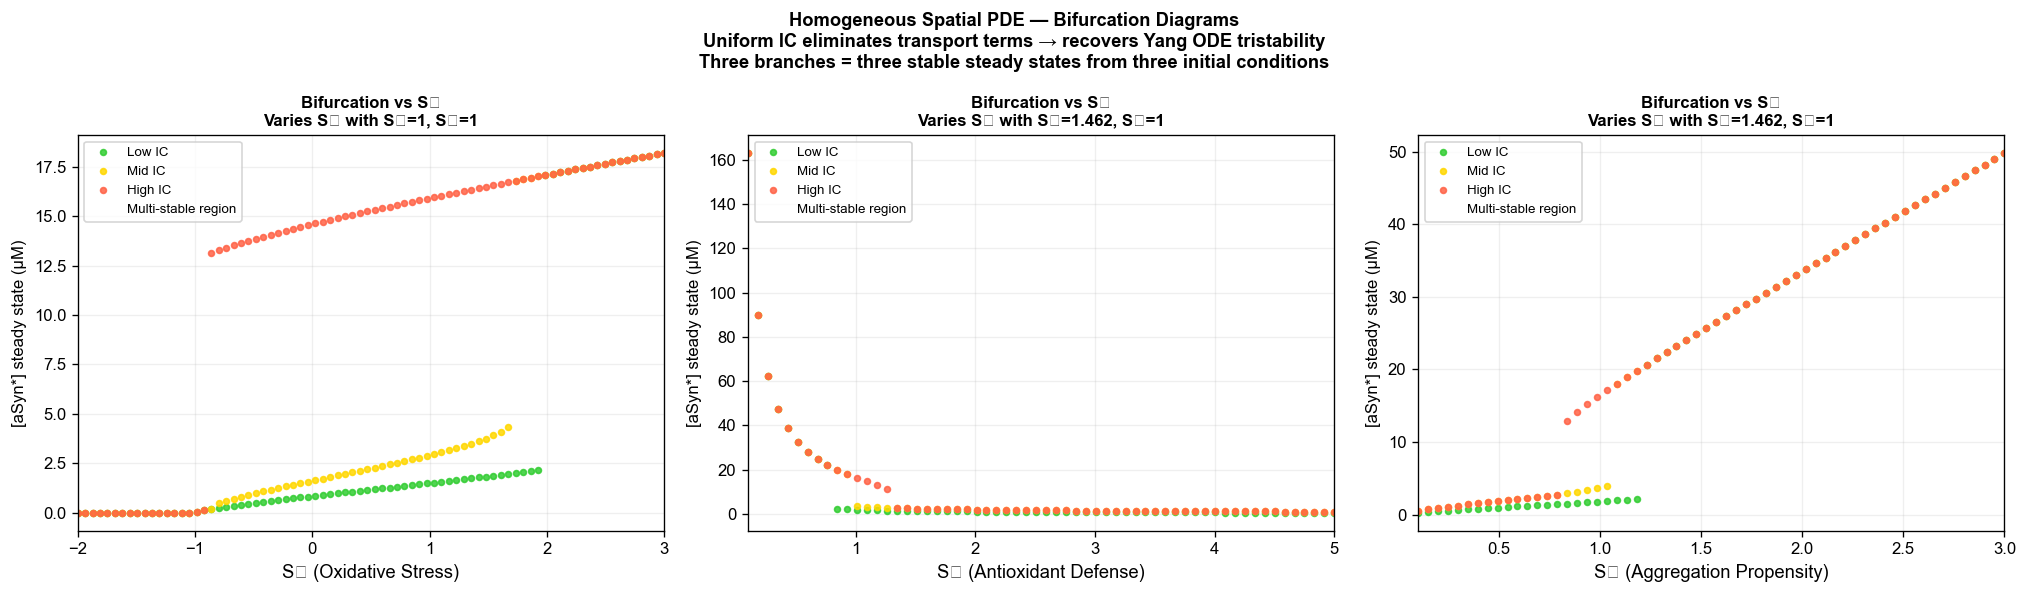

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sweep_data = [
    (axes[0], S1_vals, bif_S1, 'S\u2081 (Oxidative Stress)',
     'Varies S\u2081 with S\u2082=1, S\u2083=1',
     [-2, 3]),
    (axes[1], S2_vals, bif_S2, 'S\u2082 (Antioxidant Defense)',
     'Varies S\u2082 with S\u2081=1.462, S\u2083=1',
     [0.1, 5.0]),
    (axes[2], S3_vals, bif_S3, 'S\u2083 (Aggregation Propensity)',
     'Varies S\u2083 with S\u2081=1.462, S\u2082=1',
     [0.1, 3.0]),
]

for ax, x_vals, bif_data, xlabel, subtitle, xlim in sweep_data:

    for lbl, sp_dict in bif_data.items():
        ss_vals = sp_dict['aSyn*']   # extract aSyn* specifically
        col     = IC_colors[lbl]
        ax.plot(x_vals, ss_vals, 'o', ms=3.5,
                color=col, alpha=0.85,
                label=lbl.split('→')[0].strip())

    # Shade regions where branches separate (bistable/tristable)
    low  = np.array(bif_data[list(IC_sets.keys())[0]]['aSyn*'])
    high = np.array(bif_data[list(IC_sets.keys())[2]]['aSyn*'])
    sep  = np.abs(high - low) > 0.5
    if np.any(sep):
        x_sep = x_vals[sep]
        ax.axvspan(x_sep[0], x_sep[-1],
                   alpha=0.07, color='white',
                   label='Multi-stable region')

    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('[aSyn*] steady state (\u03bcM)', fontsize=10)
    ax.set_title(f'Bifurcation vs {xlabel.split("(")[0].strip()}\n'
                 f'{subtitle}',
                 fontsize=10, fontweight='bold')
    ax.set_xlim(xlim)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(alpha=0.2)

plt.suptitle(
    'Homogeneous Spatial PDE — Bifurcation Diagrams\n'
    'Uniform IC eliminates transport terms → recovers Yang ODE tristability\n'
    'Three branches = three stable steady states from three initial conditions',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('bifurcation_all_params.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ── Print all 6 variables at each SS for the reference tristable point ────────
print("=" * 80)
print("COMPLETE STEADY STATE VALUES — All Variables, S1=1.462, S2=1, S3=1")
print("=" * 80)
print(f"\n{'State':<16} {'ROS':>8} {'aSyn*':>8} {'ERS':>8} "
      f"{'mTOR':>8} {'Beclin1':>8} {'Casp':>8}")
print("-" * 70)

for label, (ss, state) in ss_verified.items():
    print(f"{state:<16} " +
          "  ".join([f"{v:8.4f}" for v in ss]))

print("\nKey observations:")
print(f"  Beclin1: highest at Healthy ({ss_verified['Low IC → Healthy'][0][4]:.4f} µM)"
      f" — autophagy maximally active")
print(f"  Caspases: highest at Disease ({ss_verified['High IC → Disease'][0][5]:.4f} µM)"
      f" — apoptosis committed")
print(f"  mTOR: similar across states ({min(ss_verified[k][0][3] for k in ss_verified):.3f}"
      f"–{max(ss_verified[k][0][3] for k in ss_verified):.3f} µM)"
      f" — retrograde transport redistributes evenly")

COMPLETE STEADY STATE VALUES — All Variables, S1=1.462, S2=1, S3=1

State                 ROS    aSyn*      ERS     mTOR  Beclin1     Casp
----------------------------------------------------------------------
Healthy            2.4931    1.8150    0.9515    0.6675    0.7621    0.1179
Intermediate       2.9864    3.7083    1.2993    0.8384    0.3558    0.9243
Disease           16.4712   16.4825    1.7836    0.8522    0.4343    0.9388

Key observations:
  Beclin1: highest at Healthy (0.7621 µM) — autophagy maximally active
  Caspases: highest at Disease (0.9388 µM) — apoptosis committed
  mTOR: similar across states (0.668–0.852 µM) — retrograde transport redistributes evenly


/var/folders/s4/k2c6nj9n4371mjry_0bbj6180000gn/T/ipykernel_25489/162238521.py:48: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/s4/k2c6nj9n4371mjry_0bbj6180000gn/T/ipykernel_25489/162238521.py:49: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.savefig('homogeneous_flatness_check.png', dpi=150)
/Users/nitinshreyes/anaconda3/envs/BENG227/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


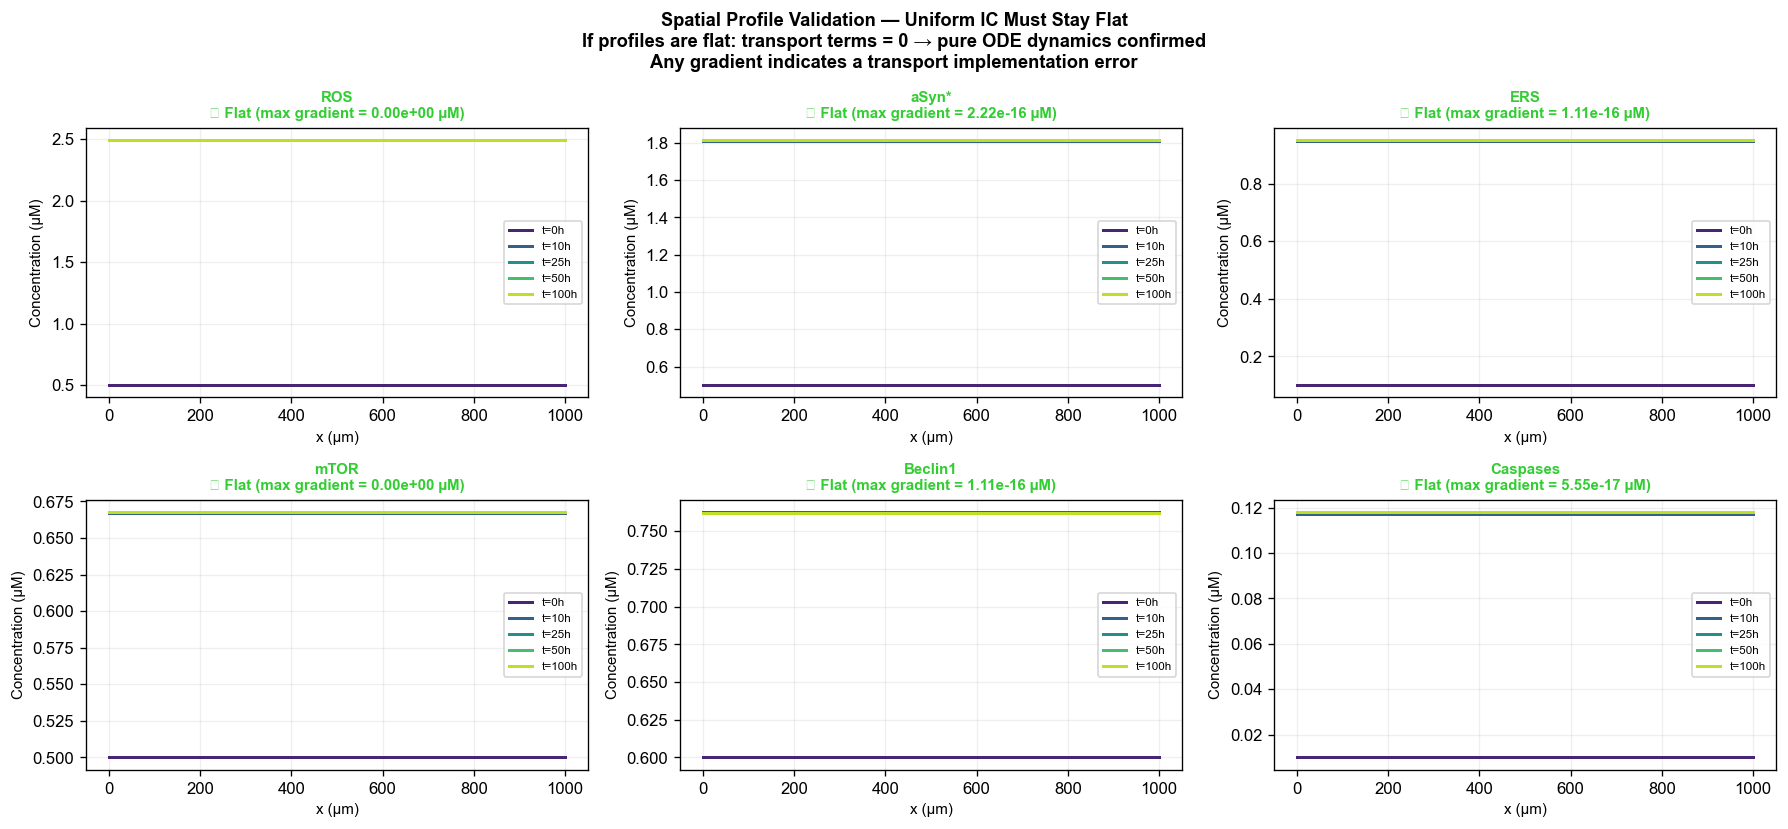


Spatial uniformity check (max−min over x at t=100h):
  ROS         : 0.00e+00 µM  ✓ FLAT
  aSyn*       : 2.22e-16 µM  ✓ FLAT
  ERS         : 1.11e-16 µM  ✓ FLAT
  mTOR        : 0.00e+00 µM  ✓ FLAT
  Beclin1     : 1.11e-16 µM  ✓ FLAT
  Caspases    : 5.55e-17 µM  ✓ FLAT


In [9]:
# ── Confirm: with uniform IC, spatial profile stays flat throughout ───────────
# If any gradient develops, something is wrong with the transport implementation

p_check = {**CFG, 'S1': 1.462}
ic_test  = IC_sets['Low IC → Healthy']
y0_test  = homogeneous_ic(ic_test, Nx)

sol_check = solve_ivp(
    pde_rhs_yang, (0, 100), y0_test,
    args     = (p_check, dx, Nx),
    method   = 'Radau',
    t_eval   = np.linspace(0, 100, 200),
    rtol     = 1e-8, atol = 1e-10,
    max_step = 1.0
)

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flat
t_snaps = [0, 10, 25, 50, 100]
colors_t = plt.cm.viridis(np.linspace(0.1, 0.9, len(t_snaps)))

for sp_idx, (sp_name, ax) in enumerate(zip(species_names, axes)):
    for ti, ts in enumerate(t_snaps):
        t_idx  = np.argmin(np.abs(sol_check.t - ts))
        field  = sol_check.y[sp_idx*Nx:(sp_idx+1)*Nx, t_idx]
        ax.plot(x, field, color=colors_t[ti], lw=1.8, label=f't={ts}h')

        # Check flatness
        spatial_var = np.max(field) - np.min(field)
        if spatial_var > 1e-6:
            ax.set_title(f'{sp_name}\n⚠ Gradient = {spatial_var:.2e} µM',
                         fontsize=9, color='tomato', fontweight='bold')
        else:
            ax.set_title(f'{sp_name}\n✓ Flat (max gradient = {spatial_var:.2e} µM)',
                         fontsize=9, color='limegreen', fontweight='bold')

    ax.set_xlabel('x (µm)', fontsize=9)
    ax.set_ylabel('Concentration (µM)', fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.2)

plt.suptitle(
    'Spatial Profile Validation — Uniform IC Must Stay Flat\n'
    'If profiles are flat: transport terms = 0 → pure ODE dynamics confirmed\n'
    'Any gradient indicates a transport implementation error',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('homogeneous_flatness_check.png', dpi=150)
plt.show()

# Final numerical check
print("\nSpatial uniformity check (max−min over x at t=100h):")
for sp_idx, sp_name in enumerate(species_names):
    field = sol_check.y[sp_idx*Nx:(sp_idx+1)*Nx, -1]
    grad  = np.max(field) - np.min(field)
    status = "✓ FLAT" if grad < 1e-6 else "⚠ GRADIENT PRESENT"
    print(f"  {sp_name:<12}: {grad:.2e} µM  {status}")

In [10]:
# ── Final validation: spatial PDE SS must match Yang ODE SS exactly ───────────
from scipy.integrate import solve_ivp as solve_ode

def yang_ode_pure(t, y, p):
    """Yang ODE without any spatial terms — ground truth."""
    ROS, A, ERS, mTOR, B1, Casp = [max(v, 0.0) for v in y]
    Hill   = (A/p['K'])**p['n'] / (1 + (A/p['K'])**p['n'])
    dROS   = p['k1']*(1+p['S1']+p['d_aSyn']*Hill) - p['k2']*ROS*p['S2']
    dA     = p['k3']*ROS*p['S3'] - p['k4']*p['k5']*A*B1*mTOR
    dERS   = p['k6']*A*p['k7']*(p['ERST']-ERS) - p['k8']*ERS
    MT     = p['mTORT']
    dM     = (p['k9']+p['k10']*ERS)*(MT-mTOR) - (p['k11']+p['k12']*B1)*mTOR
    BT     = p['Beclin1T']
    act_B  = (p['k13']+p['k14']*ERS)*(BT-B1)/(p['Jbe']+BT-B1+1e-12)
    inh_B  = (p['k15']+p['k16']*Casp+p['k17']*mTOR)*B1/(p['Jbe']+B1+1e-12)
    dB1    = act_B - inh_B
    CT     = p['CaspasesT']
    act_C  = (p['k18']+p['k19']*ERS+p['k20']*mTOR)*(CT-Casp)/(p['Jca']+CT-Casp+1e-12)
    inh_C  = (p['k21']+p['k22']*B1)*Casp/(p['Jca']+Casp+1e-12)
    dCasp  = act_C - inh_C
    return [dROS, dA, dERS, dM, dB1, dCasp]


print("=" * 80)
print("SPATIAL PDE vs YANG ODE — Steady State Comparison")
print("(Should match to numerical tolerance — validates spatial model)")
print("=" * 80)

p_val = {**CFG, 'S1': 1.462}

for label, ic in IC_sets.items():
    # Spatial PDE SS
    _, ss_pde = run_homogeneous(p_val, ic)

    # Yang ODE SS
    sol_ode  = solve_ode(yang_ode_pure, (0, 800), ic,
                         args=(p_val,), method='Radau',
                         rtol=1e-10, atol=1e-12)
    ss_ode   = sol_ode.y[:, -1]

    max_err  = np.max(np.abs(ss_pde - ss_ode))
    rel_err  = np.max(np.abs((ss_pde - ss_ode)/(ss_ode + 1e-10)))

    print(f"\n  {label}")
    print(f"  {'Species':<12} {'PDE SS':>10} {'ODE SS':>10} {'|Error|':>12}")
    print(f"  {'─'*46}")
    for i, sp in enumerate(species_names):
        print(f"  {sp:<12} {ss_pde[i]:>10.6f} {ss_ode[i]:>10.6f} "
              f"{abs(ss_pde[i]-ss_ode[i]):>12.2e}")
    print(f"  Max absolute error : {max_err:.2e} µM")
    print(f"  Max relative error : {rel_err:.2e}")
    verdict = "✓ MATCH" if max_err < 1e-4 else "⚠ MISMATCH — check RHS"
    print(f"  Verdict            : {verdict}")

SPATIAL PDE vs YANG ODE — Steady State Comparison
(Should match to numerical tolerance — validates spatial model)

  Low IC → Healthy
  Species          PDE SS     ODE SS      |Error|
  ──────────────────────────────────────────────
  ROS            2.493118   2.493118     4.44e-16
  aSyn*          1.814995   1.814995     2.22e-16
  ERS            0.951506   0.951506     2.22e-16
  mTOR           0.667543   0.667543     3.33e-16
  Beclin1        0.762122   0.762122     1.11e-16
  Caspases       0.117916   0.117916     1.39e-17
  Max absolute error : 4.44e-16 µM
  Max relative error : 4.99e-16
  Verdict            : ✓ MATCH

  Mid IC → Intermediate
  Species          PDE SS     ODE SS      |Error|
  ──────────────────────────────────────────────
  ROS            2.986381   2.986381     1.33e-15
  aSyn*          3.708270   3.708270     1.33e-15
  ERS            1.299262   1.299262     6.66e-16
  mTOR           0.838371   0.838371     2.22e-16
  Beclin1        0.355774   0.355774     3.33

In [11]:
from scipy.optimize import fsolve
from scipy.linalg import eigvals as speigvals
import warnings

def find_all_fps_param(p, n_seeds=500, tol=1e-8):
    """
    Find ALL fixed points (stable + unstable) at parameter set p.
    Returns list of (fp, is_stable, max_re_lambda)
    """
    def rhs(y): return yang_ode_pure(0, y, p)

    fps = []
    rng = np.random.default_rng(42)

    # Seed over physiological range
    seeds = rng.uniform(
        low  = [0.0,  0.0,  0.0, 0.0, 0.0, 0.0],
        high = [20.0, 20.0, 2.0, 1.0, 1.0, 1.0],
        size = (n_seeds, 6)
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for s in seeds:
            try:
                fp, info, ier, _ = fsolve(rhs, s, full_output=True)
                if ier != 1: continue
                if np.max(np.abs(rhs(fp))) > tol: continue
                if np.any(fp < -1e-4): continue
                is_new = all(not np.allclose(fp, e[0], atol=1e-3)
                             for e in fps)
                if is_new:
                    # Compute Jacobian eigenvalues
                    J    = numerical_jacobian(fp, p)
                    eigs = speigvals(J)
                    max_re = np.max(np.real(eigs))
                    stable = max_re < 0
                    fps.append((fp, stable, max_re))
            except: continue

    return fps


def numerical_jacobian(fp, p, eps=1e-6):
    n  = len(fp)
    J  = np.zeros((n, n))
    f0 = np.array(yang_ode_pure(0, fp, p))
    for j in range(n):
        yp = fp.copy(); yp[j] += eps
        J[:, j] = (np.array(yang_ode_pure(0, yp, p)) - f0) / eps
    return J


def bifurcation_fsolve(param_name, param_vals, base_cfg):
    """
    Trace all branches (stable + unstable) using fsolve.
    Returns:
        stable_fps:   list of (param_val, aSyn*, full_fp)
        unstable_fps: list of (param_val, aSyn*, full_fp)
    """
    stable_pts   = []
    unstable_pts = []

    for i, val in enumerate(param_vals):
        p    = {**base_cfg, param_name: val}
        fps  = find_all_fps_param(p)

        for fp, is_stable, max_re in fps:
            A_ss = fp[1]
            if is_stable:
                stable_pts.append((val, A_ss, fp, max_re))
            else:
                unstable_pts.append((val, A_ss, fp, max_re))

        if i % 10 == 0:
            n_s = sum(1 for v,_,_,_ in stable_pts if abs(v-val)<1e-9)
            n_u = sum(1 for v,_,_,_ in unstable_pts if abs(v-val)<1e-9)
            print(f"  {param_name}={val:.3f}: "
                  f"{n_s} stable, {n_u} unstable FPs", end='\r')

    print(f"\n  Done. Total: {len(stable_pts)} stable, "
          f"{len(unstable_pts)} unstable points")
    return stable_pts, unstable_pts

In [15]:
import time

# ── S1 sweep ─────────────────────────────────────────────────────────────────
S1_vals = np.linspace(-2.0, 3.0, 100)
print("S1 bifurcation sweep (fsolve)...")
t0 = time.time()
S1_stable, S1_unstable = bifurcation_fsolve(
    'S1', S1_vals, {**CFG, 'S2': 1.0, 'S3': 1.0}
)
print(f"  S1 done in {time.time()-t0:.1f}s")

# ── S2 sweep ─────────────────────────────────────────────────────────────────
S2_vals = np.linspace(0.1, 3.0, 80)   # was 0.2–4.0

print("S2 bifurcation sweep (fsolve)...")
t0 = time.time()
S2_stable, S2_unstable = bifurcation_fsolve(
    'S2', S2_vals, {**CFG, 'S1': 1.462, 'S3': 1.0}
)
print(f"  S2 done in {time.time()-t0:.1f}s")

# ── S3 sweep ─────────────────────────────────────────────────────────────────
S3_vals = np.linspace(0.1, 2.0, 80)   # was 0.1–2.5
print("S3 bifurcation sweep (fsolve)...")
t0 = time.time()
S3_stable, S3_unstable = bifurcation_fsolve(
    'S3', S3_vals, {**CFG, 'S1': 1.462, 'S2': 1.0}
)
print(f"  S3 done in {time.time()-t0:.1f}s")

S1 bifurcation sweep (fsolve)...
  S1=2.545: 1 stable, 0 unstable FPs
  Done. Total: 198 stable, 118 unstable points
  S1 done in 13.5s
S2 bifurcation sweep (fsolve)...
  S2=2.670: 2 stable, 1 unstable FPs
  Done. Total: 149 stable, 70 unstable points
  S2 done in 11.1s
S3 bifurcation sweep (fsolve)...
  S3=1.784: 1 stable, 0 unstable FPs
  Done. Total: 139 stable, 59 unstable points
  S3 done in 11.0s


/var/folders/s4/k2c6nj9n4371mjry_0bbj6180000gn/T/ipykernel_25489/3367107635.py:155: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/s4/k2c6nj9n4371mjry_0bbj6180000gn/T/ipykernel_25489/3367107635.py:155: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/s4/k2c6nj9n4371mjry_0bbj6180000gn/T/ipykernel_25489/3367107635.py:155: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/s4/k2c6nj9n4371mjry_0bbj6180000gn/T/ipykernel_25489/3367107635.py:156: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig('bifurcation_fsolve.png', dpi=150, bbox_inches='tight')
/var/folders/s4/k2c6nj9n4371mjry_0bbj6180000gn/T/ipykernel_25489/3367107635.py:156: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig('bifurcation_fsolve.png', dpi=150, bbox_inches='tight')
/var/folders/s4

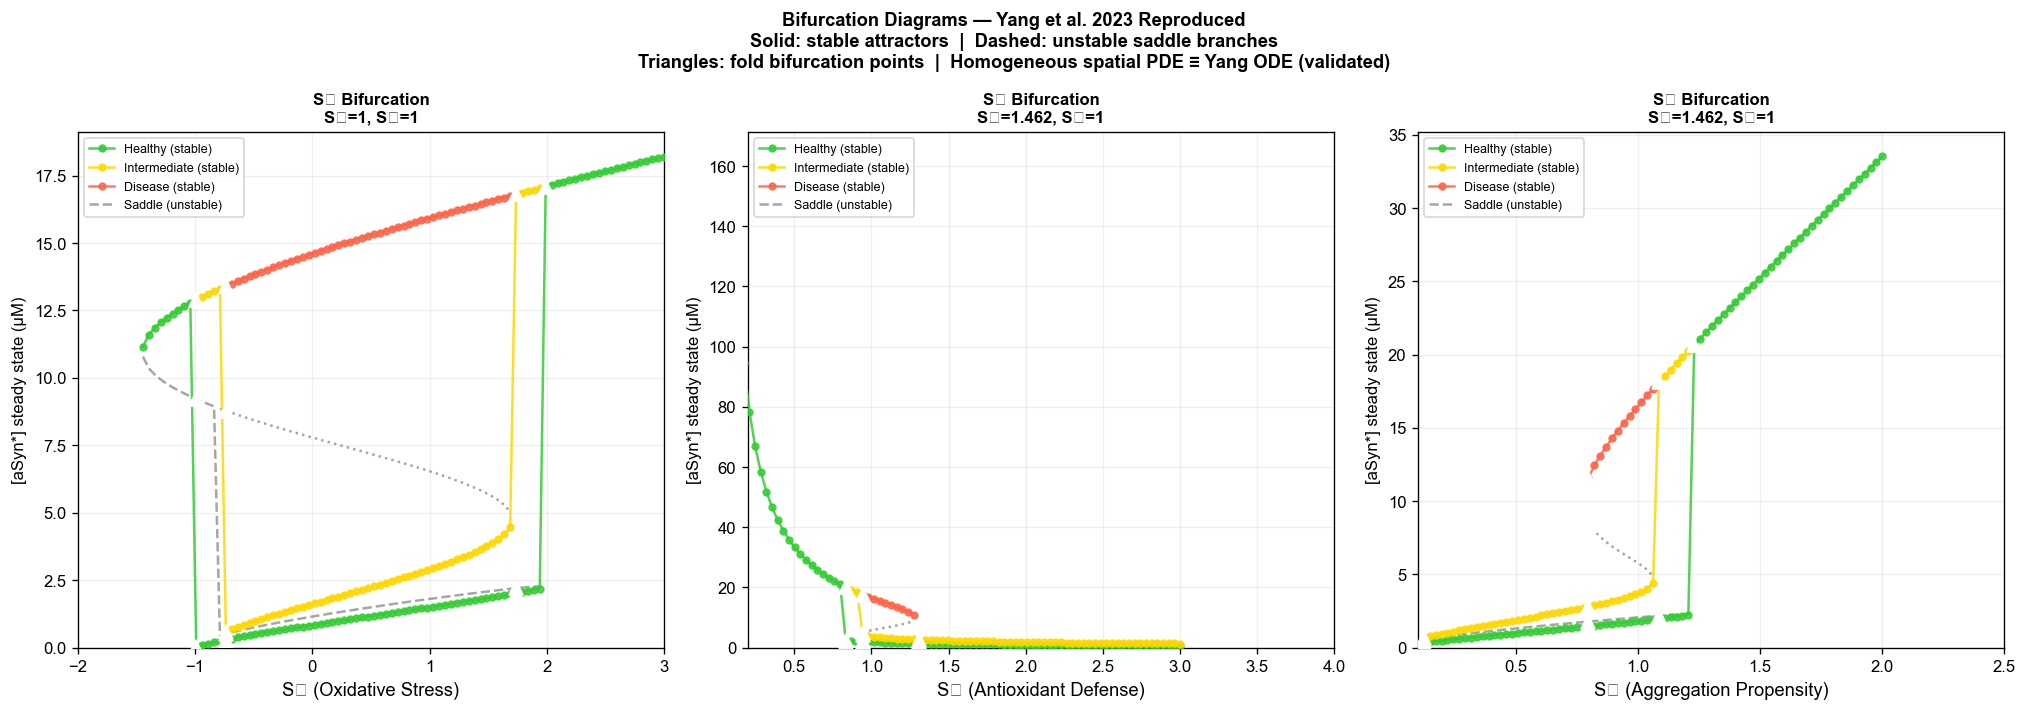

In [16]:
def clean_branches(pts, tol=0.3):
    """
    Given list of (param_val, aSyn*, fp, max_re),
    deduplicate points that are within tol of each other
    at the same parameter value.
    Returns cleaned list.
    """
    cleaned = []
    for val in sorted(set(v for v,_,_,_ in pts)):
        group = [(v,A,fp,mr) for v,A,fp,mr in pts if abs(v-val) < 1e-9]
        # Sort by aSyn* and keep only distinct ones
        group.sort(key=lambda x: x[1])
        kept = [group[0]]
        for item in group[1:]:
            if abs(item[1] - kept[-1][1]) > tol:
                kept.append(item)
        cleaned.extend(kept)
    return cleaned


def split_stable_branches(stable_pts):
    """
    Adaptively split stable fixed points into branches
    without hardcoded thresholds.
    At each parameter value, sort FPs by aSyn* and assign:
    branch 0 = lowest, branch 1 = middle, branch 2 = highest
    """
    # Group by parameter value
    from collections import defaultdict
    by_param = defaultdict(list)
    for v, A, fp, mr in stable_pts:
        by_param[v].append((A, fp, mr))

    branches = {0: [], 1: [], 2: []}   # low, mid, high
    for v in sorted(by_param.keys()):
        fps_at_v = sorted(by_param[v], key=lambda x: x[0])
        for idx, (A, fp, mr) in enumerate(fps_at_v):
            if idx <= 2:
                branches[idx].append((v, A))

    return branches


fig, axes = plt.subplots(1, 3, figsize=(17, 6))

branch_colors  = {0: 'limegreen', 1: 'gold', 2: 'tomato'}
branch_labels  = {0: 'Healthy (stable)',
                  1: 'Intermediate (stable)',
                  2: 'Disease (stable)'}

sweep_configs = [
    (axes[0], S1_stable, S1_unstable,
     'S\u2081 (Oxidative Stress)',    'S\u2082=1, S\u2083=1',   [-2, 3]),
    (axes[1], S2_stable, S2_unstable,
     'S\u2082 (Antioxidant Defense)', 'S\u2081=1.462, S\u2083=1', [0.2, 4.0]),
    (axes[2], S3_stable, S3_unstable,
     'S\u2083 (Aggregation Propensity)','S\u2081=1.462, S\u2082=1', [0.1, 2.5]),
]

for ax, stable_pts, unstable_pts, xlabel, subtitle, xlim in sweep_configs:

    if not stable_pts:
        ax.text(0.5, 0.5, 'No data', transform=ax.transAxes,
                ha='center', color='white')
        continue

    # ── Clean duplicates ──────────────────────────────────────────────────
    stable_clean   = clean_branches(stable_pts,   tol=0.3)
    unstable_clean = clean_branches(unstable_pts, tol=0.3)

    # ── Split stable into branches ────────────────────────────────────────
    branches = split_stable_branches(stable_clean)

    for b_idx, pts in branches.items():
        if not pts: continue
        xs = np.array([v for v,_ in pts])
        ys = np.array([A for _,A in pts])
        idx = np.argsort(xs)
        ax.plot(xs[idx], ys[idx],
                'o-', ms=4, lw=1.5,
                color=branch_colors[b_idx],
                alpha=0.85,
                label=branch_labels[b_idx],
                zorder=3)

    # ── Unstable (saddle) branches ────────────────────────────────────────
    if unstable_clean:
        # Split saddles into upper and lower by aSyn*
        from collections import defaultdict
        by_param_u = defaultdict(list)
        for v, A, fp, mr in unstable_clean:
            by_param_u[v].append(A)

        # Two saddle branches: lower saddle and upper saddle
        lower_sad, upper_sad = [], []
        for v in sorted(by_param_u.keys()):
            As = sorted(by_param_u[v])
            if len(As) >= 1: lower_sad.append((v, As[0]))
            if len(As) >= 2: upper_sad.append((v, As[1]))

        for sad_pts, ls in [(lower_sad, '--'), (upper_sad, ':')]:
            if not sad_pts:
                continue
            xs = np.array([v for v,_ in sad_pts])
            ys = np.array([A for _,A in sad_pts])
            idx = np.argsort(xs)
            ax.plot(xs[idx], ys[idx],
                    ls, lw=1.5, color='gray', alpha=0.7,
                    label='Saddle (unstable)' if ls == '--' else '_',
                    zorder=2)

    # ── Fold bifurcation points ───────────────────────────────────────────
    # Find parameter values where number of stable FPs changes
    from collections import defaultdict
    n_stable_by_param = defaultdict(int)
    for v, A, _, _ in stable_clean:
        n_stable_by_param[v] += 1

    prev_n = None
    for v in sorted(n_stable_by_param.keys()):
        n = n_stable_by_param[v]
        if prev_n is not None and n != prev_n:
            # Fold point — mark all FPs at this value
            ys_at_fold = [A for vv,A,_,_ in stable_clean if abs(vv-v)<1e-9]
            ys_at_fold += [A for vv,A,_,_ in unstable_clean if abs(vv-v)<1e-9]
            for yf in ys_at_fold:
                ax.plot(v, yf, 'w^', ms=8, zorder=6,
                        label='Fold bifurcation' if prev_n is None else '_')
        prev_n = n

    # ── Formatting ────────────────────────────────────────────────────────
    # Deduplicate legend entries
    handles, labels = ax.get_legend_handles_labels()
    seen = {}
    for h, l in zip(handles, labels):
        if l not in seen and not l.startswith('_'):
            seen[l] = h
    ax.legend(seen.values(), seen.keys(), fontsize=7.5, loc='upper left')

    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('[aSyn*] steady state (\u03bcM)', fontsize=10)
    ax.set_title(f'{xlabel.split("(")[0].strip()} Bifurcation\n{subtitle}',
                 fontsize=10, fontweight='bold')
    ax.set_xlim(xlim)
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.2)

plt.suptitle(
    'Bifurcation Diagrams — Yang et al. 2023 Reproduced\n'
    'Solid: stable attractors  |  Dashed: unstable saddle branches\n'
    'Triangles: fold bifurcation points  |  '
    'Homogeneous spatial PDE \u2261 Yang ODE (validated)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('bifurcation_fsolve.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
print("=" * 70)
print("BIFURCATION SUMMARY")
print("=" * 70)

for param_name, param_vals, stable_pts, unstable_pts in [
    ('S1', S1_vals, S1_stable, S1_unstable),
    ('S2', S2_vals, S2_stable, S2_unstable),
    ('S3', S3_vals, S3_stable, S3_unstable),
]:
    print(f"\n  Parameter: {param_name}")
    print(f"  {'─'*55}")

    # Count FPs at each parameter value
    fp_counts = {}
    for val in param_vals:
        n_s = sum(1 for v,_,_,_ in stable_pts   if abs(v-val)<1e-6)
        n_u = sum(1 for v,_,_,_ in unstable_pts if abs(v-val)<1e-6)
        fp_counts[val] = (n_s, n_u, n_s+n_u)

    # Find windows
    mono_healthy  = [v for v,(ns,nu,nt) in fp_counts.items()
                     if nt == 1 and
                     any(A < 3 for vv,A,_,_ in stable_pts if abs(vv-v)<1e-6)]
    bistable      = [v for v,(ns,nu,nt) in fp_counts.items()
                     if nt == 3 and ns == 2]
    tristable     = [v for v,(ns,nu,nt) in fp_counts.items()
                     if ns == 3]
    mono_disease  = [v for v,(ns,nu,nt) in fp_counts.items()
                     if nt == 1 and
                     any(A > 10 for vv,A,_,_ in stable_pts if abs(vv-v)<1e-6)]

    if mono_healthy:
        print(f"  Monostable healthy  : {param_name} < {max(mono_healthy):.3f}")
    if bistable:
        print(f"  Bistable window     : {min(bistable):.3f} – {max(bistable):.3f}")
    if tristable:
        print(f"  Tristable window    : {min(tristable):.3f} – {max(tristable):.3f}")
    if mono_disease:
        print(f"  Monostable disease  : {param_name} > {min(mono_disease):.3f}")

    total_stable   = len(stable_pts)
    total_unstable = len(unstable_pts)
    print(f"\n  Total stable pts   : {total_stable}")
    print(f"  Total unstable pts : {total_unstable}")

BIFURCATION SUMMARY

  Parameter: S1
  ───────────────────────────────────────────────────────
  Bistable window     : -0.990 – 1.939
  Tristable window    : -0.788 – 1.687
  Monostable disease  : S1 > 1.990

  Total stable pts   : 198
  Total unstable pts : 118

  Parameter: S2
  ───────────────────────────────────────────────────────
  Bistable window     : 0.834 – 3.000
  Tristable window    : 0.944 – 1.275
  Monostable disease  : S2 > 0.100

  Total stable pts   : 149
  Total unstable pts : 70

  Parameter: S3
  ───────────────────────────────────────────────────────
  Bistable window     : 0.100 – 1.206
  Tristable window    : 0.797 – 1.062
  Monostable disease  : S3 > 1.230

  Total stable pts   : 139
  Total unstable pts : 59
